<a href="https://colab.research.google.com/github/withfablue/PyTorch/blob/main/Chapter2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

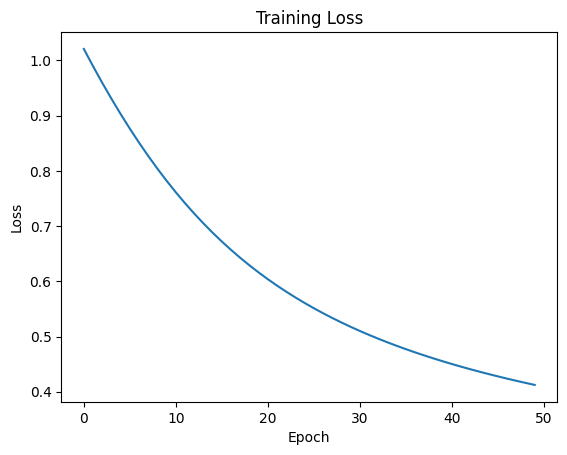

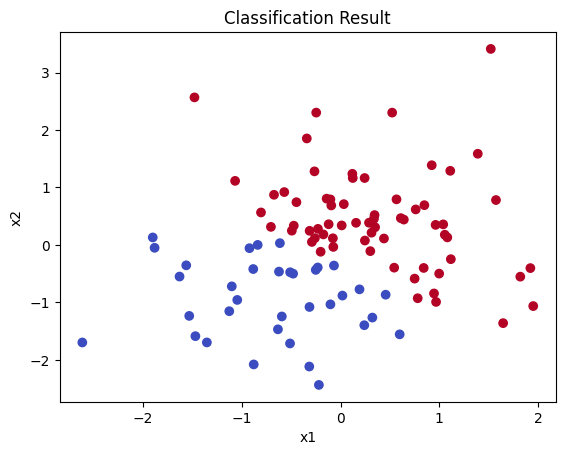

In [ ]:
# 선형 분류 모델 구현하기
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 데이터 생성
# shape: X(100, 2), y(100,)
torch.manual_seed(0)
X = torch.randn(100,2)
y = (X[:, 0] + X[:, 1] > 0).long()

# 모델 정의
model = nn.Sequential(
    nn.Linear(2,1),    # shape: (batch, 1)
    nn.Sigmoid()
)

criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

loss_history = []

# 학습
for epoch in range(50):
  optimizer.zero_grad()
  output = model(X).squeeze()    # shape: (100,)
  loss = criterion(output, y.float())
  loss.backward()
  optimizer.step()
  loss_history.append(loss.item())

# 손실 곡선 시각화
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# 분류 결과 시각화
with torch.no_grad():
  preds = (model(X).squeeze() > 0.5).long()

plt.scatter(X[:, 0], X[:, 1], c=preds, cmap='coolwarm')
plt.title("Classification Result")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

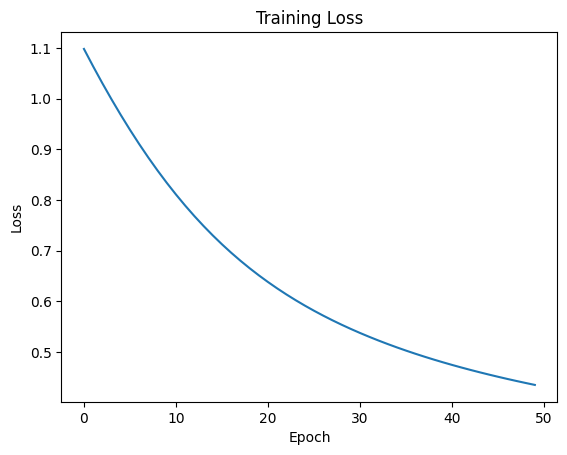

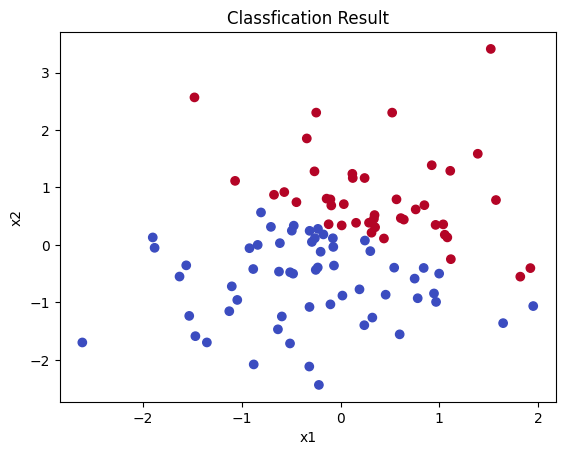

In [ ]:
# 직접 쓰기
# 선형 분류 모델 구현하기

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 데이터 생성
torch.manual_seed(0)
X = torch.randn(100, 2)
y = (X[:, 0] + X[:, 1] > 0.5).long()

# 모델 정의
model = nn.Sequential(
    nn.Linear(2, 1),
    nn.Sigmoid()
)

criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

loss_history = []

# 학습
for epoch in range(50):
  optimizer.zero_grad()
  output = model(X).squeeze()
  loss = criterion(output, y.float())
  loss.backward()
  optimizer.step()
  loss_history.append(loss.item())

# 손실 곡선 시각화
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# 분류 결과 시각화
with torch.no_grad():
  preds = (model(X).squeeze() > 0.5).long()

plt.scatter(X[:, 0], X[:, 1], c=preds, cmap='coolwarm')
plt.title("Classfication Result")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

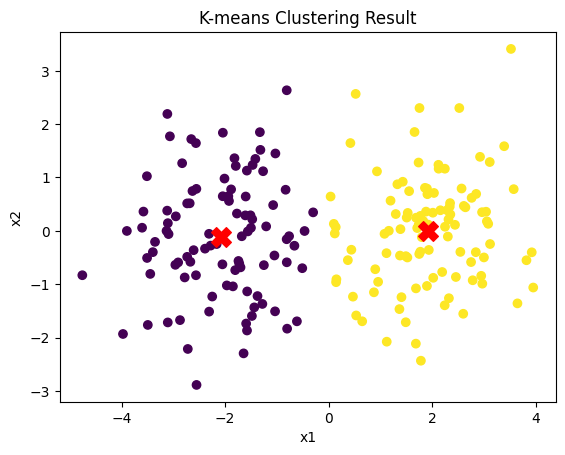

In [ ]:
# K-means 군집화 및 시각화하기

import torch
import matplotlib.pyplot as plt

# 데이터 생성
# shape: (200, 2)
torch.manual_seed(0)
X = torch.cat([
    torch.randn(100,2) + torch.tensor([2.0, 0.0]),
    torch.randn(100,2) + torch.tensor([-2.0, 0.0])
], dim=0)

# 초기 중심점 선택
# shape: (2, 2)
centroids = X[torch.randperm(X.size(0))[:2]]
for _ in range(20):
  # 각 점이 가장 가까운 중심점을 선택
  distances = torch.cdist(X, centroids)   # shape: (200, 2)
  labels = distances.argmin(dim=1)  # shape: (200,)

  # 새 중심점 계산
  new_centroids = torch.stack([X[labels==i].mean(dim=0) for i in range(2)])

  if torch.allclose(centroids, new_centroids):
    break
  centroids = new_centroids

  # 군집 결과 시각화
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis')
plt.scatter(centroids[:,0], centroids[:,1], c='red', s=200, marker='X')
plt.title("K-means Clustering Result")
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

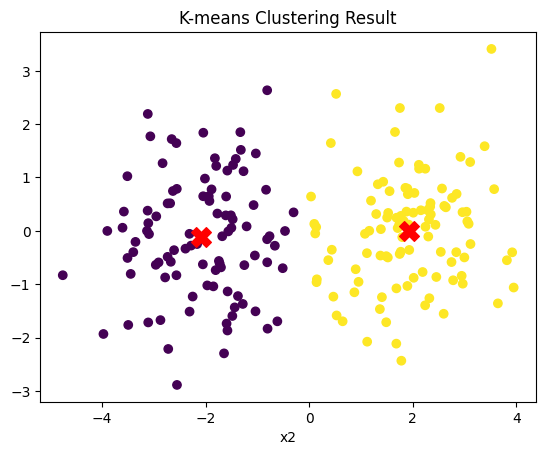

In [ ]:
# K-means 군집화 및 시각화하기
import torch
import matplotlib.pyplot as plt

# 데이터 생성
# shape (200,2)
torch.manual_seed(0)
X = torch.cat([
    torch.randn(100,2) + torch.tensor([2.0, 0.0]),
    torch.randn(100,2) + torch.tensor([-2.0, 0.0])
], dim=0)

#print(X.shape)

# 초기 중심점 선택
# shape (2, 2)
centroids = X[torch.randperm(X.size(0))[:2]]
for _ in range(20):
  # 각 점이 가장 가까운 중심점을 선택
  distances = torch.cdist(X, centroids)  # shape (200,2)
  labels = distances.argmin(dim=1)  # shape (200,)

  # 새 중심점 계산
  new_centroids = torch.stack([X[labels==i].mean(dim=0) for i in range(2)])

  if torch.allclose(centroids, new_centroids):
    break
  centroids = new_centroids

# 군집 결과 시각화
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis')
plt.scatter(centroids[:,0], centroids[:,1], c='red', s=200, marker='X')
plt.title("K-means Clustering Result")
plt.xlabel("x1")
plt.xlabel("x2")
plt.show()